In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd

path = "/content/drive/MyDrive/IMDB Dataset.csv"
df = pd.read_csv(path)

df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [3]:
df.shape

(50000, 2)

In [4]:
df.isnull().sum()

,0
review,0
sentiment,0


In [5]:
df.drop_duplicates(inplace=True)
df.shape
df = df.sample(frac=1).reset_index(drop=True)  # shuffle

# **Pre-processing**

  1.Converting to Lower case

In [6]:
df["review"]=df["review"].str.lower()

2.Removing URLs

In [7]:
import re
def remove_urls(text):
  text=re.sub(r"http\S+", "", text)
  return text
df["review"]=df["review"].apply(remove_urls)

3.Remove Punctuations

In [8]:
def remove_punctuations(text):
  text=re.sub(r"[^A-Za-z0-9\s]", "", text)
  return text
df["review"]=df["review"].apply(remove_punctuations)

4.Remove HTML tags

In [9]:
def remove_html(text):
  text=re.sub(r"<.*?>", "", text)
  return text
df["review"]=df["review"].apply(remove_html)

5.Removing the stopwords

In [10]:
import nltk
nltk.download("punkt")
nltk.download("punkt_tab")
nltk.download("stopwords")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [11]:
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

In [12]:
def remove_stopwords(text):
  tokens=word_tokenize(text)
  stop_words=stopwords.words('english')

  for word in tokens:
    if word in stop_words:
      text=text.replace(word,"")

  return text
df["review"]=df["review"].apply(remove_stopwords)

In [13]:
df.head()

,review,sentiment
0,scientt workg frnticlly seclusion fds wy lo...,positive
1,cnt get much eerier fltlers deep drk film ...,positive
2,tlly rdculous know nythng poker fnd blut...,negative
3,s blowgun ssss tkes vctms ngr flls d new yk...,negative
4,flm hrble scrpt completely unreltc yet w...,negative


6.Stemming(Porter Stemming)

In [14]:
def stemming(text):
  ps=nltk.PorterStemmer()
  stemmed_words=[]
  tokens=word_tokenize(text)
  for token in tokens:
    stemmed_token=ps.stem(token)
    stemmed_words.append(stemmed_token)

  return " ".join(stemmed_words)
df["review"]=df["review"].apply(stemming)


In [15]:
df.head()

,review,sentiment
0,scientt workg frnticlli seclus fd wy loct impc...,positive
1,cnt get much eerier fltler deep drk film rt pu...,positive
2,tlli rdculou know nythng poker fnd blute pplln...,negative
3,s blowgun ssss tke vctm ngr fll d new yk cy ge...,negative
4,flm hrble scrpt complet unreltc yet wrten tke ...,negative


7.Encoding

In [16]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df["sentiment"] = le.fit_transform(df["sentiment"])
y=df["sentiment"]
y

,sentiment
0,1
1,1
2,0
3,0
4,0
...,...
49577,1
49578,0
49579,1
49580,1


8.Vectorization

In [17]:
from sklearn.feature_extraction.text import TfidfVectorizer

tf=TfidfVectorizer(max_features=5000)
X=tf.fit_transform(df['review'])

In [18]:
X

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 4057161 stored elements and shape (49582, 5000)>

In [19]:
print(X)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 4057161 stored elements and shape (49582, 5000)>
  Coords	Values
  (0, 3705)	0.12595161330829394
  (0, 4885)	0.10973953068376872
  (0, 1420)	0.06402521753937422
  (0, 4958)	0.04104641349514138
  (0, 2320)	0.10117722362185218
  (0, 2048)	0.12713867724303918
  (0, 753)	0.11778291841496136
  (0, 746)	0.12357784044939624
  (0, 2782)	0.05824304154430159
  (0, 1201)	0.08754758007842069
  (0, 2290)	0.06534572156952652
  (0, 2746)	0.12349576558572524
  (0, 4316)	0.12120132866015834
  (0, 4424)	0.08156599559119655
  (0, 14)	0.11377854336789715
  (0, 3392)	0.05422929458815748
  (0, 3561)	0.09083001779167958
  (0, 528)	0.0894506423199581
  (0, 2040)	0.0959839021376204
  (0, 4404)	0.15525098612137558
  (0, 658)	0.046551546949259635
  (0, 2910)	0.10046397665372045
  (0, 2045)	0.11901282466658471
  (0, 3267)	0.11432734394033094
  (0, 1846)	0.1845781100265659
  :	:
  (49581, 3684)	0.07903585400379708
  (49581, 3167)	0.08586762391049871
  (

# Dataset and DataLoaders

In [20]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.2,random_state=42
)

In [21]:
X_train.shape

(39665, 5000)

In [22]:
X_test.shape

(9917, 5000)

In [23]:
import numpy as np
from scipy.sparse import csr_matrix
import torch
from torch.utils.data import TensorDataset, DataLoader

X_train=X_train.toarray()
X_test=X_test.toarray()
trainset=TensorDataset(
    torch.from_numpy(X_train).float(),
    torch.from_numpy(y_train.values).float()
)
testset=TensorDataset(
    torch.from_numpy(X_test).float(),
    torch.from_numpy(y_test.values).float()
)
trainloader=DataLoader(trainset,batch_size=64,shuffle=True)
test_loader=DataLoader(testset,batch_size=64,shuffle=False)

Build our RNN

In [24]:
import torch.nn as nn
import torch.optim as optim
class RNN(nn.Module):
  def __init__(self, input_size, hidden_size=128, num_layers=1):
    super(RNN, self).__init__()

    self.hidden_size = hidden_size
    self.num_layers = num_layers

    ##RNN layer
    self.rnn = nn.RNN(input_size, hidden_size, num_layers, batch_first=True)
    ## fully connected layer(many to one)
    self.fc=nn.Linear(hidden_size,1)

  def forward(self,x):
    #optional => shape(num of layers,batch size,hidden size)
    h0=torch.zeros(self.num_layers, x.size(0), self.hidden_size)
    out,_=self.rnn(x,h0)
    #1st value=hidden state of all the timesteps =>(batch,seq_len,hidden size)
    #2nd value = final hidden state of last timestamp

    out=self.fc(out[:,-1,:])
    return out

In [25]:
input_size=X_train.shape[1]
model=RNN(input_size)
criterion = nn.BCEWithLogitsLoss()
optimizer=optim.Adam(model.parameters())


Training the RNN

In [26]:
epochs = 10

for epoch in range(epochs):
  model.train()

  for Xb,yb in trainloader:
    optimizer.zero_grad()

    Xb=Xb.unsqueeze(1) # add singleton direction
    outputs=model(Xb)
    #outputs=torch.sigmoid(outputs.squeeze()) # batch,size  => probability
    loss=criterion(outputs.squeeze(),yb)
    loss.backward()
    optimizer.step()

  print(f"epoch = {epoch+1}/{epochs} and loss = {loss.item()}")

epoch = 1/10 and loss = 0.2983744740486145
epoch = 2/10 and loss = 0.17913168668746948
epoch = 3/10 and loss = 0.13929620385169983
epoch = 4/10 and loss = 0.23752741515636444
epoch = 5/10 and loss = 0.20398254692554474
epoch = 6/10 and loss = 0.22347375750541687
epoch = 7/10 and loss = 0.19148920476436615
epoch = 8/10 and loss = 0.24076218903064728
epoch = 9/10 and loss = 0.3349853456020355
epoch = 10/10 and loss = 0.24226990342140198


In [27]:
model.eval()
with torch.no_grad():
  correct_vals=0
  tot_vals=0

  for Xb,yb in test_loader:
    Xb=Xb.unsqueeze(1);

    outputs=model(Xb)
    predicted=(torch.sigmoid(outputs.squeeze()) >0.5).float()
    tot_vals+=yb.size(0)
    correct_vals+=(predicted==yb).sum().item()


  print(f"Accuracy = {correct_vals/tot_vals*100}")

Accuracy = 86.04416658263587


In [28]:
def predict_review(text):
    model.eval()

    # === SAME preprocessing as training ===
    text = text.lower()
    text = remove_urls(text)
    text = remove_punctuations(text)
    text = remove_html(text)
    text = remove_stopwords(text)
    text = stemming(text)

    # === TF-IDF transform (IMPORTANT) ===
    vec = tf.transform([text]).toarray()

    # === Convert to tensor ===
    tensor = torch.from_numpy(vec).float().unsqueeze(1)

    # === Prediction ===
    with torch.no_grad():
        output = model(tensor)
        prob = torch.sigmoid(output).item()

    sentiment = "Positive" if prob >= 0.5 else "Negative"

    print(f"Review: {text}")
    print(f"Sentiment: {sentiment}")
    print(f"Confidence: {prob*100:.2f}%")

In [29]:
predict_review("This movie was amazing, I loved it")
predict_review("Worst film ever, total waste of time")

Review: move amazng love t
Sentiment: Positive
Confidence: 99.66%
Review: worst film ever total wast time
Sentiment: Negative
Confidence: 0.01%


Confusion Matrix

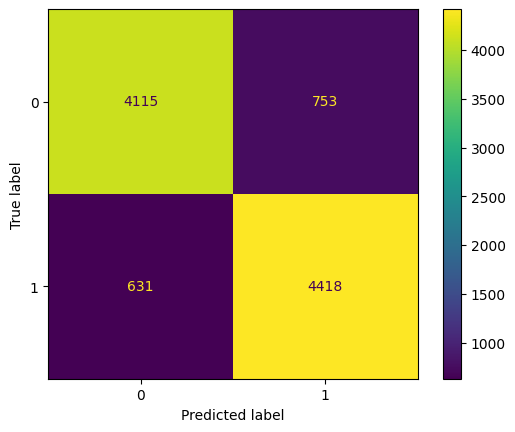

In [30]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

all_preds = []
all_labels = []

model.eval()
with torch.no_grad():
    for Xb, yb in test_loader:
        Xb = Xb.unsqueeze(1)
        outputs = model(Xb)
        preds = (torch.sigmoid(outputs.squeeze()) > 0.5).cpu().numpy()

        all_preds.extend(preds)
        all_labels.extend(yb.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

Accuracy / Precision / Recall / F1

In [32]:
from sklearn.metrics import classification_report

print(classification_report(all_labels, all_preds))

              precision    recall  f1-score   support

         0.0       0.87      0.85      0.86      4868
         1.0       0.85      0.88      0.86      5049

    accuracy                           0.86      9917
   macro avg       0.86      0.86      0.86      9917
weighted avg       0.86      0.86      0.86      9917



Probability Distribution Plot

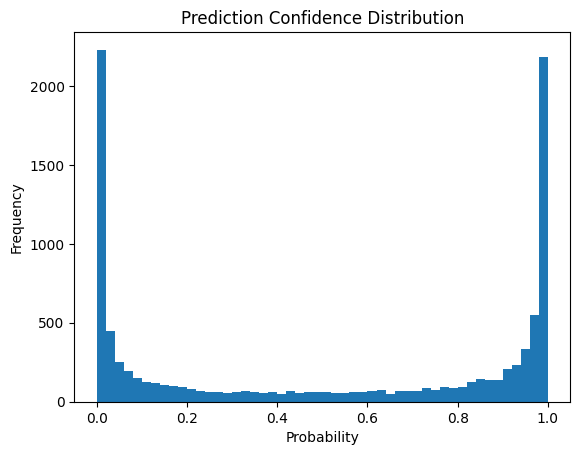

In [33]:
probs = []

model.eval()
with torch.no_grad():
    for Xb, yb in test_loader:
        Xb = Xb.unsqueeze(1)
        outputs = model(Xb)
        prob = torch.sigmoid(outputs.squeeze()).cpu().numpy()
        probs.extend(prob)

plt.hist(probs, bins=50)
plt.title("Prediction Confidence Distribution")
plt.xlabel("Probability")
plt.ylabel("Frequency")
plt.show()

Error Analysis

In [34]:
wrong_samples = []

model.eval()
with torch.no_grad():
    for Xb, yb in test_loader:
        Xb = Xb.unsqueeze(1)
        outputs = model(Xb)
        prob = torch.sigmoid(outputs.squeeze())
        preds = (prob > 0.5).float()

        for i in range(len(preds)):
            if preds[i] != yb[i]:
                wrong_samples.append((prob[i].item(), yb[i].item()))

print("Number of wrong predictions:", len(wrong_samples))

Number of wrong predictions: 1384


Positive vs Negative Prediction Count

In [36]:
import numpy as np

all_preds = np.array(all_preds)

print("Positive predictions:", np.sum(all_preds == 1))
print("Negative predictions:", np.sum(all_preds == 0))

Positive predictions: 5171
Negative predictions: 4746


ROC Curve

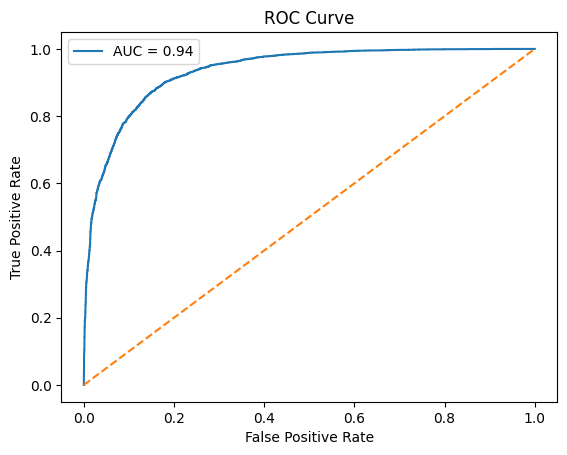

In [37]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(all_labels, probs)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

Misclassified Reviews

In [38]:
wrong_reviews = []

model.eval()
with torch.no_grad():
    for Xb, yb in test_loader:
        Xb = Xb.unsqueeze(1)
        outputs = model(Xb)
        prob = torch.sigmoid(outputs.squeeze())
        preds = (prob > 0.5).float()

        for i in range(len(preds)):
            if preds[i] != yb[i]:
                wrong_reviews.append((prob[i].item(), yb[i].item()))

print("Some wrong predictions:", wrong_reviews[:10])

Some wrong predictions: [(0.2763184607028961, 1.0), (0.08935016393661499, 1.0), (0.4035559594631195, 1.0), (0.48383358120918274, 1.0), (0.2835477590560913, 1.0), (0.20148497819900513, 1.0), (0.7546014785766602, 0.0), (0.6578956246376038, 0.0), (0.5328084230422974, 0.0), (0.42817553877830505, 1.0)]
